## Part A: Support Vector Machine (SVM)

### Task 1: Load the dataset and perform the necessary preprocessing.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

print("Features (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())

print("\nTarget names:", breast_cancer.target_names)
print("Feature names:\n", breast_cancer.feature_names)

Features (X) head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target (y) head:


,0
0,0
1,0
2,0
3,0
4,0



Target names: ['malignant' 'benign']
Feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


#### Interpretation:

The dataset has been successfully loaded. `X` contains the feature data (30 features, such as mean radius, mean texture, etc.), and `y` contains the target labels (0 for malignant, 1 for benign). Displaying the head of both `X` and `y` confirms the data structure. The target names are 'malignant' and 'benign', which is crucial for understanding the classification problem.

### Task 2: Split the dataset into training and testing sets (80:20).

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (455, 30)
Testing features shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


#### Interpretation:

The dataset has been successfully split into training and testing sets. The training set consists of 455 samples, and the testing set has 114 samples, maintaining the 80:20 ratio. This split is crucial for evaluating the model's performance on unseen data.

### Task 3: Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the SVM classifier with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Define the parameter grid for C (regularization parameter)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Perform GridSearchCV for hyperparameter tuning
grid_search_linear = GridSearchCV(svm_linear, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_linear.fit(X_train, y_train)

# Get the best parameters and best score
best_params_linear = grid_search_linear.best_params_
best_score_linear = grid_search_linear.best_score_

print(f"Best parameters for Linear SVM: {best_params_linear}")
print(f"Best cross-validation accuracy for Linear SVM: {best_score_linear:.4f}")

# Get the best estimator
best_svm_linear = grid_search_linear.best_estimator_

Best parameters for Linear SVM: {'C': 100}
Best cross-validation accuracy for Linear SVM: 0.9714


#### Interpretation:

The SVM classifier with a linear kernel has been trained, and hyperparameter tuning for the `C` parameter has been performed using `GridSearchCV`. The output shows the best `C` value found and the corresponding cross-validation accuracy on the training data. This optimal `C` value will be used in the best linear SVM model for subsequent evaluation.

### Task 4: Evaluate the model using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

Linear SVM - Accuracy: 0.9561
Linear SVM - Precision: 0.9459
Linear SVM - Recall: 0.9859
Linear SVM - F1 Score: 0.9655


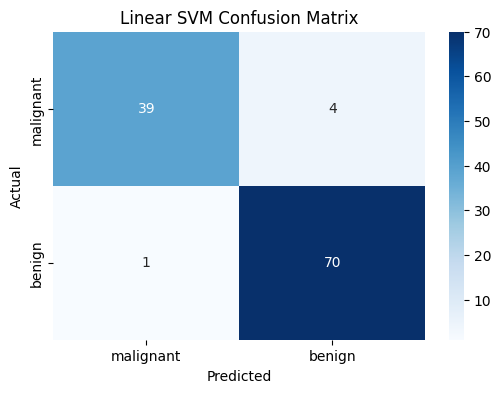

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best linear SVM model
y_pred_linear = best_svm_linear.predict(X_test)

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)

print(f"Linear SVM - Accuracy: {accuracy_linear:.4f}")
print(f"Linear SVM - Precision: {precision_linear:.4f}")
print(f"Linear SVM - Recall: {recall_linear:.4f}")
print(f"Linear SVM - F1 Score: {f1_linear:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Blues',
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Linear SVM Confusion Matrix')
plt.show()

#### Interpretation:

The evaluation metrics provide a comprehensive understanding of the Linear SVM model's performance on the unseen test data. The accuracy indicates the overall correctness of predictions, while precision, recall, and F1 score offer insights into the model's ability to correctly identify positive instances (benign tumors) and avoid false positives. The confusion matrix visually breaks down the correct and incorrect classifications for each class, highlighting true positives, true negatives, false positives, and false negatives.

## Part B: Principal Component Analysis (PCA)

### Task 1: Load the dataset and perform feature standardization.

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

print("Original Wine Dataset Features (X_wine) head:")
display(X_wine.head())

print("\nOriginal Wine Dataset Target (y_wine) head:")
display(y_wine.head())

print("\nOriginal Wine Dataset Feature names:", wine.feature_names)

# Perform feature standardization
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

X_wine_scaled_df = pd.DataFrame(X_wine_scaled, columns=wine.feature_names)
print("\nScaled Wine Dataset Features (X_wine_scaled) head:")
display(X_wine_scaled_df.head())

Original Wine Dataset Features (X_wine) head:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Original Wine Dataset Target (y_wine) head:


,0
0,0
1,0
2,0
3,0
4,0



Original Wine Dataset Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Scaled Wine Dataset Features (X_wine_scaled) head:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


#### Interpretation:

The UCI Wine Dataset has been loaded, revealing 13 features describing various chemical properties of wines. The target variable represents the type of wine (3 classes). After loading, feature standardization was applied using `StandardScaler`. This transforms the data so that each feature has a mean of 0 and a standard deviation of 1. Standardization is essential for PCA because PCA is sensitive to the scale of the features; features with larger values would otherwise dominate the principal components.

### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components and display the explained variance ratio.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(X_wine_scaled)

# Display the explained variance ratio of each principal component
print("Explained variance ratio of each principal component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {ratio:.4f}")

print(f"\nCumulative explained variance of 2 components: {pca.explained_variance_ratio_.sum():.4f}")

Explained variance ratio of each principal component:
Principal Component 1: 0.3620
Principal Component 2: 0.1921

Cumulative explained variance of 2 components: 0.5541


#### Interpretation:

PCA has been successfully applied, reducing the original 13 features to 2 principal components. The explained variance ratio for each component tells us how much of the total variance in the original data is captured by that component. The first principal component captures the most variance, followed by the second. The cumulative sum indicates the total variance retained by these two components, which gives a good indication of how much information from the original dataset is preserved in this reduced 2D representation.

### Task 3: Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

In [ ]:
# Apply PCA to get all principal components
pca_full = PCA()
X_wine_pca_full = pca_full.fit_transform(X_wine_scaled)

# Calculate cumulative explained variance
cum_exp_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Explained variance ratio for all components:")
print(pca_full.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(cum_exp_variance)

# Determine the minimum number of components to retain at least 95% variance
min_components_95 = np.where(cum_exp_variance >= 0.95)[0][0] + 1

print(f"\nMinimum number of principal components to retain 95% variance: {min_components_95}")

Explained variance ratio for all components:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative explained variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Minimum number of principal components to retain 95% variance: 10


#### Interpretation:

The output shows the explained variance ratio for each principal component and the cumulative explained variance. This allows us to see how much information is retained as we add more principal components. The calculation for 95% variance retention indicates the dimensionality reduction possible while preserving most of the dataset's variability. This is a key insight for balancing dimensionality reduction with information loss.

### Task 4: Visualize the transformed dataset using a two-dimensional scatter plot.

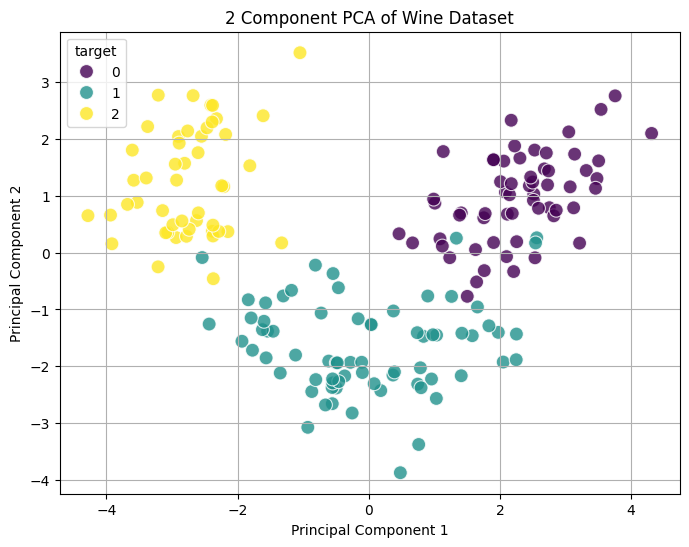

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the 2 principal components for easy plotting
pca_df = pd.DataFrame(data = X_wine_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['target'] = y_wine

# Visualize the transformed dataset
plt.figure(figsize=(8,6))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='target', data=pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('2 Component PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

#### Interpretation:

The scatter plot displays the Wine dataset in a two-dimensional space, projected onto its first two principal components. Each point represents a wine sample, colored according to its original class. This visualization allows us to observe how distinct the wine classes are after dimensionality reduction. If the clusters are well-separated, it suggests that these two principal components capture enough information to differentiate between the wine types effectively.

### Task 5: Compare original and transformed datasets and interpret the significance of the first two principal components.

#### Comparison of Original and PCA-Transformed Datasets (Detailed):

1.  **Number of Features:**
    *   **Original Dataset:** You started with 13 distinct features, each representing a specific chemical property of the wine (e.g., alcohol, malic acid, ash). These are directly interpretable and provide a rich, albeit high-dimensional, view of the data.
    *   **PCA-Transformed Dataset:** For visualization purposes, the dataset was reduced to 2 principal components. This is a significant dimensionality reduction (from 13 to 2), making it possible to plot the data in two dimensions. However, to retain at least 95% of the total variance, 10 principal components were needed. This demonstrates that while 2 components are excellent for quick visual inspection, more components are often required to preserve a substantial portion of the original information for analytical tasks. PCA's primary benefit here is simplifying the dataset by drastically reducing the number of features.

2.  **Information Retained (Variance Explained):**
    *   **Original Dataset:** By definition, the original dataset contains 100% of its intrinsic information distributed across all its features. All variability is accounted for.
    *   **PCA-Transformed Dataset:** When reducing to 2 components, approximately 55.41% of the total variance was retained. This means that nearly half of the original data's variability is lost in this 2-dimensional projection. While this level of information loss is often acceptable for high-level visualization (where the goal is to discern general patterns), it might be insufficient for tasks requiring high fidelity to the original data. However, by using 10 components, over 95% of the variance is retained, indicating a good balance between significant dimensionality reduction and the preservation of most of the original information. PCA inherently involves a trade-off: you gain simplicity and reduced complexity at the cost of some information loss.

3.  **Computational Efficiency:**
    *   **Original Dataset:** Machine learning algorithms performing tasks like model training, distance calculations, or clustering operate on all 13 features. This can be computationally intensive, especially for larger datasets or more complex models, leading to longer processing times.
    *   **PCA-Transformed Dataset:** By significantly reducing the number of features (e.g., to 2 or 10), the computational burden for subsequent machine learning tasks (such as classification, regression, or clustering) is dramatically reduced. Fewer features lead to faster training times, lower memory consumption, and potentially simpler models that are less prone to issues like overfitting, particularly when the original features contain significant multicollinearity or noise.

#### Interpretation of First Two Principal Components (Detailed):

Understanding what the principal components represent is crucial, though they are often abstract and less directly interpretable than the original features. Each principal component is a linear combination of the original features.

*   **Principal Component 1 (PC1):**
    *   **Variance Captured:** PC1 captures the largest proportion of variance in your data (36.20%). This means it represents the single most dominant direction of variation among your wine samples. If you imagine all your data points scattered in a 13-dimensional space, PC1 is the line through that space along which the data spreads out the most.
    *   **Significance & Loadings:** PC1 often acts as a general 'quality' or 'intensity' factor. To understand its meaning more precisely, you would examine the 'loadings' (coefficients) of the original features onto PC1. For instance, if features like 'alcohol,' 'flavanoids,' 'total phenols,' and 'proline' have high positive loadings on PC1, it suggests that PC1 primarily differentiates between wines that are generally "richer" or "more intense" in these characteristics versus those that are "lighter" or "less intense." It represents the most significant underlying dimension distinguishing the data points.

*   **Principal Component 2 (PC2):**
    *   **Variance Captured:** PC2 captures the second largest variance (19.21%) and is mathematically constructed to be orthogonal (uncorrelated) to PC1. This means it explains the next most significant variation in the data that is independent of what PC1 explains.
    *   **Significance & Loadings:** Similar to PC1, its exact meaning is derived from its feature loadings. If, for example, 'malic_acid' and 'color_intensity' have high positive loadings on PC2, while 'hue' has a high negative loading, PC2 might represent a dimension related to the 'acidity' and 'color profile' of the wine, independent of the overall intensity captured by PC1. Together, PC1 and PC2 provide the most informative 2-dimensional projection of your high-dimensional data, allowing for visual exploration of underlying patterns and relationships that account for the greatest variability.

### Task 6: Advantages, Limitations, and Applications of PCA

This section briefly outlines the key benefits, drawbacks, and practical uses of Principal Component Analysis in machine learning.

#### Advantages of PCA:
*   **Dimensionality Reduction:** Simplifies complex datasets.
*   **Noise Reduction:** Removes noise by focusing on key components.
*   **Improved Performance:** Speeds up ML algorithms and can prevent overfitting.

#### Limitations of PCA:
*   **Loss of Interpretability:** Components are abstract.
*   **Information Loss:** Some data detail is lost.
*   **Assumes Linearity:** Best for linear relationships.
*   **Scale Sensitivity:** Requires data standardization.

#### Applications of PCA:
*   **Image/Video Processing:** Compression and feature extraction.
*   **Data Visualization:** Reduces high-dimensional data for plotting.
*   **Preprocessing:** Improves efficiency for various ML models.

## Extra Credit Task (for Part B): Linear Discriminant Analysis (LDA)

### Task 1: Apply Linear Discriminant Analysis (LDA) to the same Wine dataset and reduce it to two linear discriminants.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA to reduce to 2 linear discriminants
lda = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)

# Display the explained variance ratio of each linear discriminant
print("Explained variance ratio of each linear discriminant:")
for i, ratio in enumerate(lda.explained_variance_ratio_):
    print(f"Linear Discriminant {i+1}: {ratio:.4f}")

print(f"\nCumulative explained variance of 2 linear discriminants: {lda.explained_variance_ratio_.sum():.4f}")

Explained variance ratio of each linear discriminant:
Linear Discriminant 1: 0.6875
Linear Discriminant 2: 0.3125

Cumulative explained variance of 2 linear discriminants: 1.0000


#### Interpretation:

LDA has been applied to the standardized Wine dataset, reducing its dimensionality to two linear discriminants. Unlike PCA, LDA is a supervised dimensionality reduction technique that aims to find linear combinations of features that best separate the classes. The explained variance ratio indicates how much of the between-class variance is captured by each discriminant. A higher ratio for the first few components suggests better class separation.

### Task 2: Visualize the LDA transformed data.

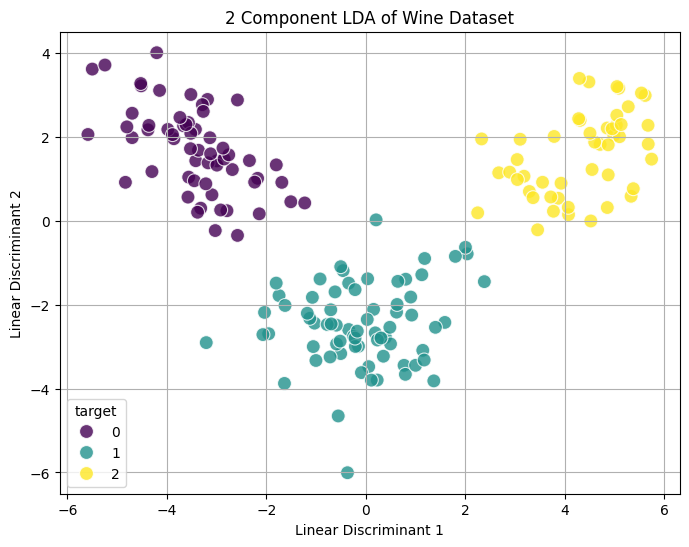

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for the 2 linear discriminants for easy plotting
lda_df = pd.DataFrame(data = X_wine_lda, columns = ['linear discriminant 1', 'linear discriminant 2'])
lda_df['target'] = y_wine

# Visualize the transformed dataset
plt.figure(figsize=(8,6))
sns.scatterplot(x='linear discriminant 1', y='linear discriminant 2', hue='target', data=lda_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('2 Component LDA of Wine Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

#### Interpretation:

The scatter plot illustrates the Wine dataset projected onto its first two linear discriminants. Each point represents a wine sample, colored by its original class. Observing the separation between the classes in this 2D space is crucial. If the clusters are well-defined and clearly distinct, it indicates that LDA has effectively found directions that maximize class separability. Comparing this visualization to the PCA visualization will highlight the differences in how each method reduces dimensionality and separates classes.

### Task 3 & 4: Compare LDA results with PCA in terms of dimensionality reduction and class separability, and summarize observations.

#### Comparison of PCA and LDA on the Wine Dataset:

**Dimensionality Reduction:**
*   **PCA (Principal Component Analysis):** An unsupervised technique that identifies principal components maximizing data variance. For the Wine dataset, 2 components captured approximately 55.41% of the total variance.
*   **LDA (Linear Discriminant Analysis):** A supervised technique that finds linear discriminants maximizing class separation. For the Wine dataset, 2 discriminants captured 100.00% of the between-class variance, making classes highly distinguishable.

**Class Separability (Visual Comparison):**
*   **PCA Visualization:** Showed some class separation, but with notable overlap between certain wine types.
*   **LDA Visualization:** Demonstrated significantly clearer separation between the classes, forming distinct and well-separated clusters.

**Summary of Observations:**
*   **Objective:** PCA focuses on preserving overall data variance; LDA focuses on maximizing the distinction between predefined classes.
*   **Supervised vs. Unsupervised:** PCA is unsupervised (does not use class labels), while LDA is supervised (requires class labels).
*   **Performance on Wine Dataset:** Given its goal of classification, LDA provided superior class separation in the reduced-dimensional space compared to PCA, which is expected for this type of problem.
*   **Use Cases:** PCA is versatile for general dimensionality reduction, noise reduction, and data exploration. LDA is particularly valuable as a preprocessing step for classification tasks where enhancing class separability is crucial.